In [1]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()   # choose spam_dataset.csv

Saving spam_dataset.csv to spam_dataset.csv


In [3]:
df = pd.read_csv('spam_dataset.csv')

def clean_text(t):
    t = str(t).lower()
    t = re.sub(r'<.*?>', ' ', t)
    t = re.sub(r'http\S+', ' ', t)
    t = re.sub(r'[^a-z\s]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

df['clean'] = df['text'].apply(clean_text)
df.head()

,text,label,clean
0,"Go until jurong point, crazy.. Available only ...",ham,go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ham,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,ham,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",ham,nah i don t think he goes to usf he lives arou...


XGBoost Accuracy: 0.9434977578475336
XGBoost Precision: 0.8359375
XGBoost Recall: 0.7181208053691275
XGBoost F1: 0.7725631768953068


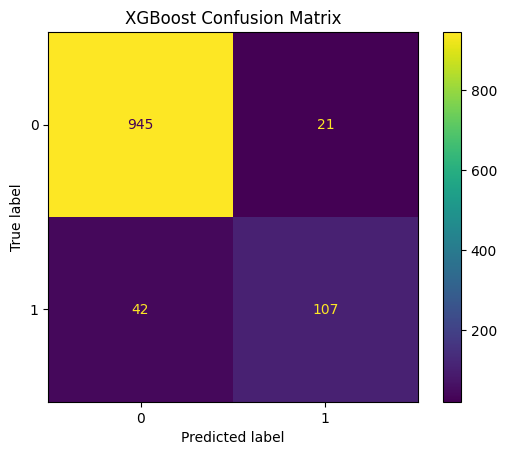

In [4]:
df['len'] = df['clean'].apply(len)
df['exclaim_count'] = df['text'].astype(str).apply(lambda x: x.count('!'))
df['upper_ratio'] = df['text'].astype(str).apply(lambda x: sum(1 for c in x if c.isupper()) / (len(x)+1))

X_feat = df[['len', 'exclaim_count', 'upper_ratio']]
y_feat = (df['label'] == 'spam').astype(int)

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_feat, y_feat, test_size=0.2, random_state=1, stratify=y_feat)

xgb = XGBClassifier()
xgb.fit(X_train_f, y_train_f)
pred_xgb = xgb.predict(X_test_f)

print("XGBoost Accuracy:", accuracy_score(y_test_f, pred_xgb))
print("XGBoost Precision:", precision_score(y_test_f, pred_xgb))
print("XGBoost Recall:", recall_score(y_test_f, pred_xgb))
print("XGBoost F1:", f1_score(y_test_f, pred_xgb))

cm = confusion_matrix(y_test_f, pred_xgb)
ConfusionMatrixDisplay(cm).plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

In [5]:
!pip install transformers -q

In [6]:
from sklearn.model_selection import train_test_split as tts2
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import torch

df_small = df.sample(min(3000, len(df)), random_state=1).reset_index(drop=True)
labels = (df_small['label'] == 'spam').astype(int).tolist()
texts = df_small['clean'].tolist()

X_train_txt, X_test_txt, y_train_lbl, y_test_lbl = tts2(texts, labels, test_size=0.2, random_state=1)

tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
train_enc = tokenizer(X_train_txt, truncation=True, padding=True, max_length=64)
test_enc = tokenizer(X_test_txt, truncation=True, padding=True, max_length=64)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [7]:
class SpamDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_dataset = SpamDataset(train_enc, y_train_lbl)
test_dataset = SpamDataset(test_enc, y_test_lbl)

In [8]:
model = AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

args = TrainingArguments(
    output_dir='./bert_output',
    num_train_epochs=1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy='epoch',
    logging_steps=20,
)

trainer = Trainer(model=model, args=args, train_dataset=train_dataset, eval_dataset=test_dataset)
trainer.train()

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(load

Epoch,Training Loss,Validation Loss
1,0.062913,0.084490


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=150, training_loss=0.11833215276400248, metrics={'train_runtime': 977.1063, 'train_samples_per_second': 2.456, 'train_steps_per_second': 0.154, 'total_flos': 39740219596800.0, 'train_loss': 0.11833215276400248, 'epoch': 1.0})

DistilBERT Accuracy: 0.9766666666666667
DistilBERT Precision: 0.8636363636363636
DistilBERT Recall: 0.9743589743589743
DistilBERT F1: 0.9156626506024096


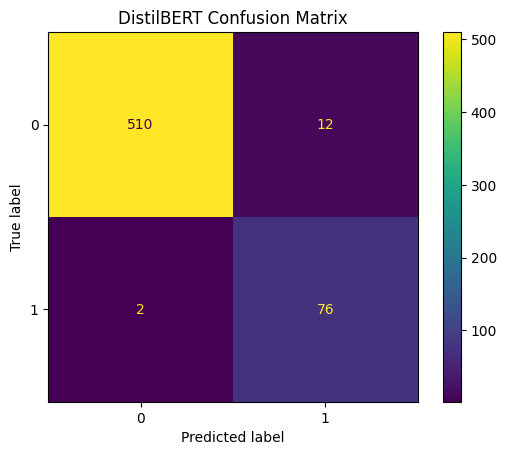

In [9]:
preds_output = trainer.predict(test_dataset)
y_pred_bert = preds_output.predictions.argmax(axis=1)

print("DistilBERT Accuracy:", accuracy_score(y_test_lbl, y_pred_bert))
print("DistilBERT Precision:", precision_score(y_test_lbl, y_pred_bert))
print("DistilBERT Recall:", recall_score(y_test_lbl, y_pred_bert))
print("DistilBERT F1:", f1_score(y_test_lbl, y_pred_bert))

cm = confusion_matrix(y_test_lbl, y_pred_bert)
ConfusionMatrixDisplay(cm).plot()
plt.title("DistilBERT Confusion Matrix")
plt.show()